<a href="https://colab.research.google.com/github/KarlaMichelleSorianoSanhez/Simulacion-I/blob/main/Metodo_para_determiar_cuando_detenerse_y_t%C3%A9cnica_de_reducci%C3%B3n_de_varianza_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Método para determinar cuándo detenerse al generar nuevos datos


**Nombre**: Karla Michelle Soriano Sánchez

**Instrucciones** : Estimar mediante simulación Monte Carlo la integral

$$
I=\int_0^1 e^{x^2}\,dx.
$$

Genere al menos 100 valores y deténgase cuando la desviación estándar de su estimador sea menor que

$$
0.01
$$

y

$$
0.001.
$$

La idea es utilizar el método estudiado para determinar cuándo detener la generación de nuevos datos.


## Solución analítica

Consideremos la integral

$$
I=\int_0^1 e^{x^2}\,dx.
$$

Esta integral no puede expresarse mediante funciones elementales. Sin embargo, puede representarse mediante la función error imaginaria definida por

$$
\operatorname{erfi}(x)
=
\frac{2}{\sqrt{\pi}}
\int_0^x e^{t^2}\,dt.
$$

Despejando la integral obtenemos

$$
\int_0^x e^{t^2}\,dt
=
\frac{\sqrt{\pi}}{2}\operatorname{erfi}(x).
$$

Evaluando entre 0 y 1,

$$
I
=
\left[
\frac{\sqrt{\pi}}{2}\operatorname{erfi}(x)
\right]_0^1.
$$

Por lo tanto,

$$
I
=
\frac{\sqrt{\pi}}{2}
\Big(
\operatorname{erfi}(1)-\operatorname{erfi}(0)
\Big).
$$

Como

$$
\operatorname{erfi}(0)=0,
$$

resulta

$$
I
=
\frac{\sqrt{\pi}}{2}\operatorname{erfi}(1).
$$

Utilizando el valor numérico

$$
\operatorname{erfi}(1)\approx 1.6504257588,
$$

obtenemos

$$
I
=
\frac{\sqrt{\pi}}{2}(1.6504257588)
\approx
1.4626517459.
$$

*Verificación mediante serie de Taylor*

Sabemos que

$$
e^{x^2}
=
\sum_{n=0}^{\infty}
\frac{x^{2n}}{n!},
$$

Integrando término a término en el intervalo $[0,1]$,

$$
I
=
\int_0^1
\sum_{n=0}^{\infty}
\frac{x^{2n}}{n!}\,dx
=
\sum_{n=0}^{\infty}
\frac{1}{n!}
\int_0^1 x^{2n}\,dx.
$$

Como

$$
\int_0^1 x^{2n}\,dx
=
\frac{1}{2n+1},
$$

obtenemos

$$
I
=
\sum_{n=0}^{\infty}
\frac{1}{(2n+1)n!}.
$$

Es decir,

$$
I
=
1+\frac{1}{3}
+\frac{1}{10}
+\frac{1}{42}
+\frac{1}{216}
+\cdots
$$

y esta serie converge al valor

$$
I\approx1.4626517459.
$$

Analiticamente se obtuvo

$$
\boxed{
\int_0^1 e^{x^2}\,dx
=
\frac{\sqrt{\pi}}{2}\operatorname{erfi}(1)
}
$$

y numéricamente

$$
\boxed{
\int_0^1 e^{x^2}\,dx
\approx
1.4626517459
}
$$

Este valor será utilizado como referencia para evaluar la precisión de las aproximaciones obtenidas mediante el método de Monte Carlo.

###Fundamento teorico

**construccion del estimador Monte Carlo**

Sea la integral

$$
I=\int_a^b g(x)\,dx.
$$

Si

$$
U\sim U(a,b),
$$

entonces su función de densidad es

$$
f_U(u)=\frac{1}{b-a},
\qquad a\le u\le b.
$$

Por definición de esperanza,

$$
E[g(U)]
=
\int_a^b g(u)\frac{1}{b-a}\,du.
$$

Multiplicando ambos lados por $(b-a)$ se obtiene

$$
(b-a)E[g(U)]
=
\int_a^b g(u)\,du.
$$

Por lo tanto,

$$
I=E[X],
$$

donde

$$
X=(b-a)g(U).
$$

Así, la integral puede estimarse mediante la media muestral de observaciones independientes de la variable aleatoria $X$.

**Variable aleatoria**

Dado que se desea estimar

$$
I=\int_0^1 e^{x^2}\,dx.
$$

Como el intervalo de integración es $[0,1]$, se genera

$$
U\sim U(0,1).
$$

La variable aleatoria asociada al estimador Monte Carlo es

$$
X=e^{U^2}.
$$

De esta manera,

$$
E[X]
=
\int_0^1 e^{u^2}\,du
=
I.
$$

Por lo tanto, el problema de estimar la integral se reduce a estimar la esperanza de la variable aleatoria $X$.

**Media muestral**

Si se generan observaciones independientes

$$
X_1,X_2,\ldots,X_k,
$$

la media muestral se define como

$$
\bar X_k
=
\frac{1}{k}
\sum_{i=1}^{k}X_i.
$$

La media muestral es un estimador insesgado de

$$
E[X].
$$

Por esta razón se utilizará

$$
\bar X_k
$$

como estimador de la integral.

**Varianza muestral**

Para medir la variabilidad de las observaciones se utiliza la varianza muestral

$$
S^2
=
\frac{
\sum_{i=1}^{k}
(X_i-\bar X_k)^2
}
{k-1}.
$$

La desviación estándar muestral está dada por

$$
S=\sqrt{S^2}.
$$

Esta cantidad proporciona una medida de la dispersión de los datos generados mediante simulación.

**Error del estimador**

La precisión de la estimación se evalúa mediante el error estándar de la media muestral.

Para una muestra de tamaño $k$ se aproxima mediante

$$
\frac{S}{\sqrt{k}}.
$$

Cuando aumenta el número de observaciones, el error estándar disminuye y la estimación se vuelve más estable.

Por esta razón, el valor

$$
\frac{S}{\sqrt{k}}
$$

se utilizará para decidir cuándo detener la simulación.

**Criterio de paro**

El método estudiado propone continuar generando observaciones hasta que

$$
\frac{S}{\sqrt{k}}
<
d,
$$

donde:

- $S$ es la desviación estándar muestral.
- $k$ es el número de observaciones generadas.
- $d$ es una tolerancia previamente fijada.

Mientras esta condición no se cumpla, se continúan generando nuevas observaciones.

En esta actividad se considerarán los valores

$$
d=0.01
$$

y

$$
d=0.001.
$$

Además, por indicación del problema, se generarán inicialmente al menos 100 observaciones antes de comenzar a verificar el criterio de paro.

**Formulas recursivas**

Con el fin de actualizar la información de manera eficiente conforme se generan nuevos datos, se utilizarán las fórmulas recursivas propuestas por Ross.

La media muestral se actualiza mediante

$$
\bar X_{j+1}
=
\bar X_j
+
\frac{X_{j+1}-\bar X_j}{j+1}.
$$

La varianza muestral se actualiza mediante

$$
S_{j+1}^{2}
=
\left(
1-\frac{1}{j}
\right)
S_j^{2}
+
(j+1)
(\bar X_{j+1}-\bar X_j)^2.
$$

Estas expresiones permiten incorporar cada nueva observación sin recalcular la media y la varianza desde el inicio de la simulación.

**Pseudocódigo del método**

1. Elegir un valor aceptable $d$ para la desviación estándar del estimador.
2. Generar al menos 30 datos.
3. Continuar generando hasta obtener $k$ valores tales que
$$
\frac{S}{\sqrt{k}} < d,
$$
donde $S$ es la desviación estándar muestral de los $k$ valores generados.

4. La estimación de $\theta$ está dada por

$$
\bar X
=
\frac{1}{k}
\sum_{i=1}^{k} X_i.
$$

In [335]:
import numpy as np
import random as r
import matplotlib.pyplot as plt

# Función especial erfi para verificar el valor analítico
from scipy.special import erfi

In [336]:
# Valor analítico de la integral

valor_real = np.sqrt(np.pi)/2 * erfi(1)

print("Valor analítico:")
print(valor_real)

Valor analítico:
1.4626517459071815


**Función para generar observaciones**

La siguiente función genera una observación de la variable aleatoria utilizada en el estimador Monte Carlo.


$$
X=e^{U^2},
\qquad U\sim U(0,1).
$$

Cada observación generada corresponde a una realización de esta variable.

In [337]:
# Generar una observación

def generar_observacion():
  # Generar número uniforme U(0,1)
  u = r.random()

  # Variable aleatoria asociada al estimador
  x = np.exp(u**2)

  return x

In [338]:
generar_observacion()

np.float64(1.0593756714255165)

**Actualización recursiva de las estadísticas muestrales**

Se implementan las fórmulas recursivas de Ross para actualizar la media y la varianza muestral sin recalcular toda la muestra en cada iteración.

In [339]:
# Actualizar media y varianza recursivamente

def act_estadisticas(j, x, media, s2):
  """
  j :Número actual de observaciones
  x :Nueva observación
  media :Media anterior
  s2 :  Varianza muestral anterior

  Retorna media y varianza muestral actualizadas.
  """
  # Caso inicial: primera observació
  if j == 0:
    return x, 0.0

  # Actualización recursiva de la media muestral
  media_act = media + (x - media)/(j + 1)

  # Actualización recursiva de la varianza muestral
  s2_act = ((j - 1)/j)*s2 + \
               (j + 1)*(media_act - media)**2

  return media_act, s2_act

**Cálcular del error estándar**

Para ello se define una función para calcular el error estándar estimado utilizado en el criterio de paro.

In [340]:
# Calcular error estándar estimado

def calcular_error_estandar(s2, k):
  # Obtener desviación estándar muestral
  s = np.sqrt(s2)

  # Calcular error estándar
  error = s / np.sqrt(k)

  return error

**Verificación del criterio de paro**

La siguiente función verifica si la precisión requerida ha sido alcanzada.

In [341]:
def verificar_paro(error, d):

  return error < d

Implementación del algoritmo Monte Carlo

Finalmente se integran todas las funciones anteriores en un único procedimiento que ejecuta automáticamente la simulación hasta satisfacer la tolerancia especificada.

In [342]:
# ==========================================================
# Método Monte Carlo con criterio de paro
# ==========================================================

def monte_carlo_paro(d, minimo=100):

    # ------------------------------------------------------
    # Listas para almacenar la evolución de la simulación
    # ------------------------------------------------------

    historial_media = []
    historial_error = []
    historial_k = []

    # ------------------------------------------------------
    # Inicializar estadísticas muestrales
    # ------------------------------------------------------

    k = 0

    media = 0.0

    s2 = 0.0

    # ------------------------------------------------------
    # Generar observaciones hasta cumplir
    # el criterio de paro
    # ------------------------------------------------------

    while True:

        # Generar nueva observación
        x = generar_observacion()

        # Actualizar media y varianza recursivamente
        media, s2 = act_estadisticas(
            k,
            x,
            media,
            s2
        )

        # Actualizar número de observaciones
        k += 1

        # Guardar evolución de la estimación
        historial_media.append(media)

        # Calcular error estándar estimado
        if k > 1:

            error = calcular_error_estandar(
                s2,
                k
            )

        else:

            error = np.inf

        # Guardar historial del error
        historial_error.append(error)

        # Guardar número de iteración
        historial_k.append(k)

        # Verificar criterio de paro
        if k >= minimo and verificar_paro(error, d):

            break

    # ------------------------------------------------------
    # Resultados finales
    # ------------------------------------------------------

    desviacion = np.sqrt(s2)

    return (
        media,
        desviacion,
        error,
        k,
        historial_media,
        historial_error,
        historial_k
    )

Se define una función auxiliar para ejecutar la simulación y mostrar los resultados obtenidos para una tolerancia dada.

In [343]:
# ==========================================================
# Ejecutar simulación para una tolerancia dada
# ==========================================================

def ejecutar_simulacion(d):

  # Ejecutar el método Monte Carlo
  estimacion, s, error, k, medias, errores, iteraciones = \
        monte_carlo_paro(d)

  # Mostrar resultados

  print(f"Tolerancia d = {d}")
  print(f"Estimación de la integral : {estimacion:.8f}")
  print(f"Desviación estándar       : {s:.8f}")
  print(f"Error estándar estimado   : {error:.8f}")
  print(f"Número de observaciones   : {k}")

  return medias, errores, iteraciones

### *Simulación para $d=0.01$*

Se ejecuta el algoritmo utilizando una tolerancia igual a $0.01$.

In [344]:
# Simulación para d = 0.01

medias_01, errores_01, iteraciones_01 = \
    ejecutar_simulacion(0.01)

Tolerancia d = 0.01
Estimación de la integral : 1.45869388
Desviación estándar       : 0.47092077
Error estándar estimado   : 0.00999924
Número de observaciones   : 2218


###  *Simulación para $d=0.001$*

Se ejecuta el algoritmo utilizando una tolerancia igual a $0.001$.

In [345]:
# Simulación para d = 0.001

medias_001, errores_001, iteraciones_001 = \
    ejecutar_simulacion(0.001)

Tolerancia d = 0.001
Estimación de la integral : 1.46283351
Desviación estándar       : 0.47462123
Error estándar estimado   : 0.00100000
Número de observaciones   : 225266


**Análisis de resultados**
## Comparación de resultados

Al reducir la tolerancia de

$$
d=0.01
$$

a

$$
d=0.001,
$$

fue necesario generar más observaciones para cumplir el criterio de paro.

Esto permitió obtener una estimación más estable y cercana al valor analítico de la integral.

**Gráficas de convergencia**

Para visualizar el comportamiento del método se presentan dos gráficas.

La primera muestra la evolución de la estimación Monte Carlo de la integral conforme aumenta el número de simulaciones.

La segunda muestra la evolución del error estándar estimado

$$
\frac{S}{\sqrt{k}},
$$

el cual se compara con la tolerancia establecida para verificar el criterio de paro.

Estas gráficas permiten observar cómo la estimación se estabiliza alrededor del valor analítico y cómo el error estándar disminuye hasta satisfacer la precisión requerida.

In [346]:
# Gráficas de convergencia

def graficar_resultados(iteraciones,
                        medias,
                        errores,
                        valor_real,
                        d):

    fig, ax = plt.subplots(1, 2, figsize=(14,5))

    # Estimación Monte Carlo

    ax[0].plot(
        iteraciones,
        medias,
        color='darkorange',
        linewidth=2,
        label='Estimación Monte Carlo'
    )

    ax[0].axhline(
        valor_real,
        color='darkgreen',
        linestyle='--',
        linewidth=2,
        label='Valor analítico'
    )

    ax[0].set_title('Convergencia de la estimación')
    ax[0].set_xlabel('Número de simulaciones')
    ax[0].set_ylabel('Estimación de la integral')
    ax[0].grid(True)
    ax[0].legend()

    # Error estándar
    ax[1].plot(
        iteraciones,
        errores,
        color='navy',
        linewidth=2,
        label='Error estándar'
    )

    ax[1].axhline(
        d,
        color='firebrick',
        linestyle='--',
        linewidth=2,
        label=f'd = {d}'
    )

    ax[1].set_title('Error estándar estimado')
    ax[1].set_xlabel('Número de simulaciones')
    ax[1].set_ylabel(r'$S/\sqrt{k}$')
    ax[1].grid(True)
    ax[1].legend()

    plt.tight_layout()
    plt.show()

*Gráficas para \(d = 0.01\)*

Se muestra el comportamiento de la estimación Monte Carlo y del error estándar cuando la tolerancia es

$$
d=0.01.
$$

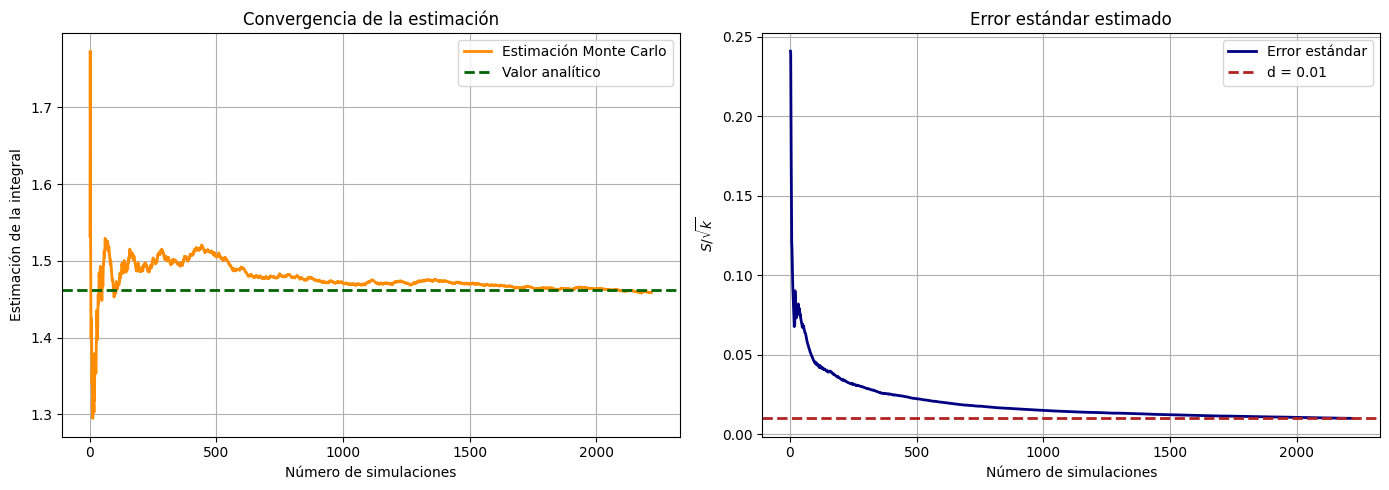

In [347]:
graficar_resultados(
    iteraciones_01,
    medias_01,
    errores_01,
    valor_real,
    0.01
)

Se observa que la estimación Monte Carlo se aproxima gradualmente al valor analítico de la integral.

Al mismo tiempo, el error estándar disminuye conforme aumenta el número de observaciones hasta ubicarse por debajo de la tolerancia establecida, momento en el que el algoritmo se detiene.

*Gráficas para $d = 0.001$*

Ahora se repite el procedimiento utilizando una tolerancia,

$$
d=0.001.
$$

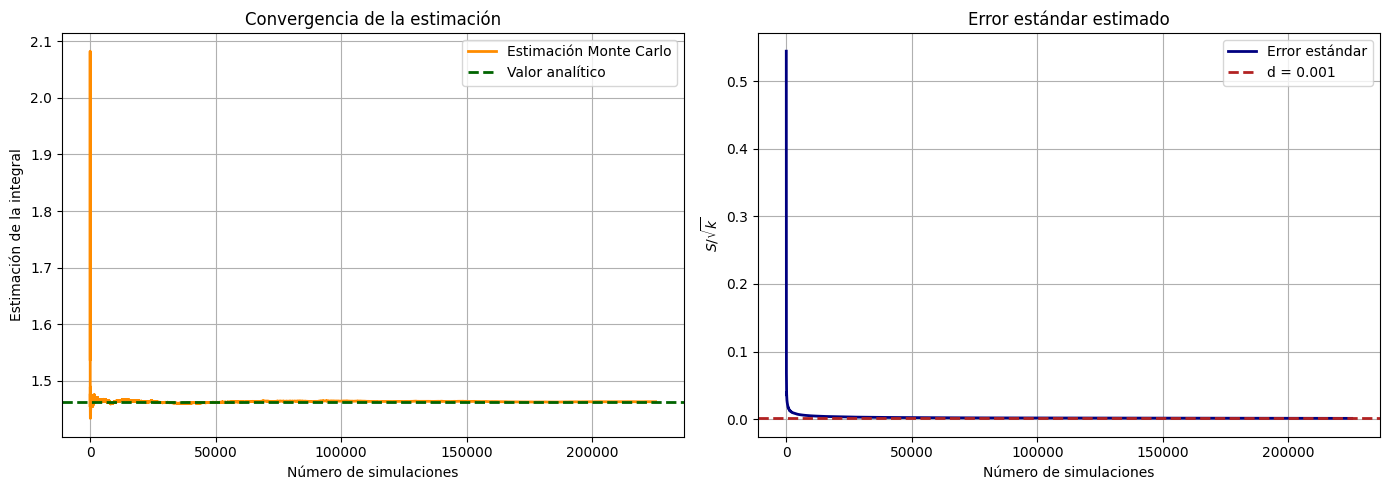

In [348]:
graficar_resultados(
    iteraciones_001,
    medias_001,
    errores_001,
    valor_real,
    0.001
)

Al exigir una tolerancia menor, el método requiere un mayor número de simulaciones para satisfacer el criterio de paro.

Como consecuencia, la estimación presenta una menor variabilidad y se mantiene más cercana al valor analítico de la integral.

**Conclusión**

Se implementó correctamente el método para determinar cuándo detener la generación de nuevos datos en una simulación Monte Carlo.

Los resultados muestran que una tolerancia más pequeña produce estimaciones más precisas, aunque requiere un mayor número de simulaciones.

Además, la estimación obtenida se aproximó adecuadamente al valor analítico de la integral.

# Técnica de reducción de varianza: Variables antitéticas

*Instrucción**: Aplicar la técnica de variables antitéticas para estimar mediante simulación Monte Carlo la integral

$$
I=\int_0^1 e^{x^2}\,dx.
$$

Comparar los resultados obtenidos con el estimador Monte Carlo estándar y analizar la reducción de varianza producida por el uso de variables antitéticas.

**Objetivo**: Implementar la técnica de variables antitéticas para mejorar la precisión de una estimación Monte Carlo.

Se busca reducir la variabilidad del estimador aprovechando la relación entre una variable uniforme

$$
U
$$

y su variable antitética

$$
1-U.
$$

Finalmente, se compararán las medias y varianzas obtenidas con las del método Monte Carlo estándar para evaluar la efectividad de la técnica.


###Fundamento teorico


**Estimador Monte Carlo estándar**

Para estimar la integral

$$
I=\int_0^1 e^{x^2}\,dx,
$$

se genera una variable aleatoria

$$
U\sim U(0,1)
$$

y se define

$$
X=e^{U^2}.
$$

Entonces,

$$
I=E[X].
$$

Una aproximación Monte Carlo de la integral está dada por

$$
\bar{X}=\frac{1}{N}\sum_{i=1}^{N} X_i.
$$

Este estimador es insesgado y converge al valor de la integral cuando el número de simulaciones aumenta.


**Idea de las variables antitéticas**

La técnica de variables antitéticas busca reducir la varianza del estimador utilizando pares de observaciones relacionadas.

Si

$$
U\sim U(0,1),
$$

entonces también

$$
1-U\sim U(0,1).
$$

Por lo tanto, para cada valor generado de \(U\) se construye su variable antitética

$$
1-U.
$$

En lugar de utilizar únicamente

$$
e^{U^2},
$$

se utilizan simultáneamente

$$
e^{U^2}
\qquad \text{y} \qquad
e^{(1-U)^2}.
$$

**Construcción del estimador antitético**

Siguiendo la idea vista en clase, para cada uniforme generado se calcula

$$
X_1=e^{U^2}
$$

y

$$
X_2=e^{(1-U)^2}.
$$

El estimador antitético se define como

$$
Y=\frac{X_1+X_2}{2}.
$$

La estimación Monte Carlo de la integral se obtiene mediante

$$
\bar{Y}
=
\frac{1}{N}
\sum_{i=1}^{N}
Y_i.
$$

**Reducción de varianza**

Las variables

$$
U
\qquad \text{y} \qquad
1-U
$$

presentan una dependencia negativa que suele producir una compensación entre los valores generados.

Como consecuencia, la varianza del estimador antitético suele ser menor que la del estimador Monte Carlo estándar.

Por esta razón, es posible obtener estimaciones más estables utilizando el mismo número de simulaciones.

**Estrategia de comparación**

Para evaluar la efectividad del método se compararán:

- La estimación Monte Carlo estándar.
- La estimación mediante variables antitéticas.
- La varianza de ambos estimadores.

La técnica será considerada efectiva si la varianza obtenida con variables antitéticas es menor que la obtenida con Monte Carlo estándar.

** Pseudocódigo del método**

Para cada número uniforme generado se construye simultáneamente su variable antitética.

Posteriormente se calcula el promedio de ambas observaciones y se utiliza como estimador de la integral.

El procedimiento general es el siguiente:

1. Generar un número aleatorio

$$
U \sim U(0,1).
$$

2. Construir la variable antitética

$$
1-U.
$$

3. Calcular

$$
X_1=e^{U^2}
$$

y

$$
X_2=e^{(1-U)^2}.
$$

4. Formar el estimador antitético

$$
Y=\frac{X_1+X_2}{2}.
$$

5. Repetir el procedimiento \(N\) veces.

6. Calcular la media muestral de los valores obtenidos.

7. Comparar la estimación y la varianza con las obtenidas mediante Monte Carlo estándar.

**Estrategia**

Se implementarán dos métodos:

- Monte Carlo estándar.
- Monte Carlo con variables antitéticas.

Posteriormente se realizarán varias repeticiones independientes para comparar la media y la varianza de ambos estimadores.

In [349]:
import numpy as np
import matplotlib.pyplot as plt
import random as r

In [350]:
# Función a integrar

def f(x):
  return np.exp(x**2)

In [351]:
f(1)

np.float64(2.718281828459045)

**Estimador Monte Carlo estándar**

Se implementa el estimador Monte Carlo tradicional utilizando observaciones independientes de una variable uniforme.

In [352]:
# Monte Carlo estándar

def mc_estandar(N):

  # Acumular observaciones simuladas
  suma = 0

  for i in range(N):
    # Generar U ~ U(0,1)
    u = r.random()

    # Evaluar la función
    suma += f(u)

  # Regresar estimación Monte Carlo
  return suma / N

**Estimador con variables antitéticas**

Para cada uniforme generado se construye simultáneamente su variable antitética y se utiliza el promedio de ambas observaciones.

In [353]:
# Monte Carlo con variables antitéticas

def mc_antitetico(N):

  # Acumular observaciones simuladas
  suma = 0

  for i in range(N):
    # Generar U ~ U(0,1)
    u = r.random()

    # Observación original
    x1 = f(u)

    # Observación antitética
    x2 = f(1 - u)

    # Promedio antitético
    suma += (x1 + x2) / 2

  # Regresar estimación Monte Carlo
  return suma / N

### Comparación de estimadores

Se realizan varias repeticiones independientes para comparar la media y la varianza de ambos estimadores.

In [354]:
L_mc = []
for i in range(100):
  L_mc.append(mc_estandar(1000))

In [355]:
L_ant = []
for i in range(100):
  L_ant.append(mc_antitetico(1000))

**Simulación del estimador Monte Carlo estándar**

Se realizan varias repeticiones independientes del estimador Monte Carlo estándar para analizar su comportamiento estadístico.

In [356]:
# Repeticiones Monte Carlo estándar

# Número de simulaciones por estimación
N = 1000

# Número de repeticiones independientes
M = 100

# Lista para almacenar estimaciones
estimaciones_mc = []

for i in range(M):
  estimaciones_mc.append( mc_estandar(N))

**Simulación del estimador antitético**

Se realizan varias repeticiones independientes utilizando variables antitéticas.

In [357]:
# Repeticiones Monte Carlo antitético

# Lista para almacenar estimaciones
estimaciones_ant = []

for i in range(M):
  estimaciones_ant.append( mc_antitetico(N))

**Estadísticas de los estimadores**

Se calculan distintas medidas descriptivas para comparar el desempeño del estimador Monte Carlo estándar y del estimador con variables antitéticas.

In [358]:
# ==========================================================
# Estadísticas Monte Carlo estándar
# ==========================================================

media_mc = np.mean(estimaciones_mc)

var_mc = np.var(
    estimaciones_mc,
    ddof=1
)

error_mc = np.sqrt(var_mc / M)

ic_mc = (
    media_mc - 1.96*error_mc,
    media_mc + 1.96*error_mc
)

# ==========================================================
# Estadísticas Monte Carlo antitético
# ==========================================================

media_ant = np.mean(estimaciones_ant)

var_ant = np.var(
    estimaciones_ant,
    ddof=1
)

error_ant = np.sqrt(var_ant / M)

ic_ant = (
    media_ant - 1.96*error_ant,
    media_ant + 1.96*error_ant
)

**Resultados obtenidos**

A continuación se presentan las estadísticas obtenidas para ambos estimadores.

In [359]:
# Mostrar resultados

print("MONTE CARLO ESTÁNDAR")

print(f"Media                    : {media_mc:.8f}")
print(f"Varianza                 : {var_mc:.8e}")
print(f"Error estándar           : {error_mc:.8e}")
print(
    f"IC 95%                   : "
    f"({ic_mc[0]:.8f}, {ic_mc[1]:.8f})"
)

print()

print("VARIABLES ANTITÉTICAS")

print(f"Media                    : {media_ant:.8f}")
print(f"Varianza                 : {var_ant:.8e}")
print(f"Error estándar           : {error_ant:.8e}")
print(
    f"IC 95%                   : "
    f"({ic_ant[0]:.8f}, {ic_ant[1]:.8f})"
)

MONTE CARLO ESTÁNDAR
Media                    : 1.46391800
Varianza                 : 2.45826115e-04
Error estándar           : 1.56788429e-03
IC 95%                   : (1.46084495, 1.46699105)

VARIABLES ANTITÉTICAS
Media                    : 1.46287639
Varianza                 : 2.71135357e-05
Error estándar           : 5.20706594e-04
IC 95%                   : (1.46185580, 1.46389697)


**Reducción de varianza**

Para cuantificar la mejora obtenida mediante variables antitéticas se compara la varianza del estimador estándar con la varianza del estimador antitético.

In [360]:
# Factor de reducción de varianza

factor_reduccion = var_mc / var_ant

print("Factor de reducción de varianza:")
print(f"{factor_reduccion:.4f}")

Factor de reducción de varianza:
9.0665


**Comparación gráfica de los estimadores**

La siguiente gráfica permite visualizar la dispersión de las estimaciones obtenidas mediante Monte Carlo estándar y mediante variables antitéticas.

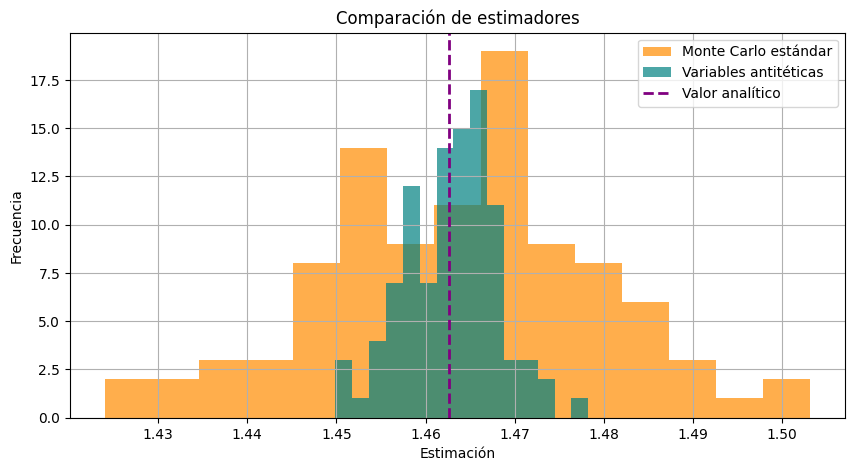

In [361]:
plt.figure(figsize=(10,5))

plt.hist(
    estimaciones_mc,
    bins=15,
    alpha=0.7,
    color="darkorange",
    label="Monte Carlo estándar"
)

plt.hist(
    estimaciones_ant,
    bins=15,
    alpha=0.7,
    color="teal",
    label="Variables antitéticas"
)

plt.axvline(
    valor_real,
    color="purple",
    linestyle="--",
    linewidth=2,
    label="Valor analítico"
)

plt.title("Comparación de estimadores")
plt.xlabel("Estimación")
plt.ylabel("Frecuencia")

plt.grid(True)
plt.legend()

plt.show()

**Interpretación**

Se observa que ambos métodos producen estimaciones cercanas al valor analítico de la integral.

Sin embargo, las estimaciones obtenidas mediante variables antitéticas presentan una menor dispersión alrededor del valor real, lo que indica una reducción de la varianza respecto al método Monte Carlo estándar.

Por lo tanto, la técnica de variables antitéticas permite obtener estimaciones más precisas utilizando el mismo número de simulaciones.

## Conclusión

Se implementó la técnica de reducción de varianza mediante variables antitéticas para estimar la integral

$$
\int_0^1 e^{x^2}\,dx.
$$

Los resultados muestran que ambos métodos producen estimaciones cercanas al valor analítico de la integral. Sin embargo, el estimador antitético presentó una varianza y un error estándar menores que los obtenidos con el método Monte Carlo estándar.

La comparación gráfica confirmó que las estimaciones antitéticas se concentran más alrededor del valor real, reflejando una mayor precisión.

Por lo tanto, las variables antitéticas constituyen una técnica efectiva para mejorar la calidad de las estimaciones Monte Carlo sin incrementar el número de simulaciones realizadas.